In [3]:
import os
from pathlib import Path

base_path = Path(r"C:\Users\smhrd\Desktop\딥페이크탐지모델\Dataset")

for split in ["Train", "Validation", "Test"]:
    print(f"\n📁 {split}")
    for label in ["Real", "Fake"]:
        folder = base_path / split / label
        count = len(list(folder.glob("*.jpg")))
        print(f"  {label}: {count}장")


📁 Train
  Real: 70001장
  Fake: 70001장

📁 Validation
  Real: 19787장
  Fake: 19641장

📁 Test
  Real: 5413장
  Fake: 5492장


In [4]:
#CELL 1 데이터 로드
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from pathlib import Path

# ─── 경로 설정 ───────────────────────────────────────────
BASE_PATH = Path(r"C:\Users\smhrd\Desktop\딥페이크탐지모델\Dataset")

TRAIN_DIR = BASE_PATH / "Train"
VAL_DIR   = BASE_PATH / "Validation"
TEST_DIR  = BASE_PATH / "Test"

# ─── Augmentation 전략 ───────────────────────────────────
# Train: 다양한 변형으로 일반화 성능 향상
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),          # 좌우 반전
    transforms.RandomRotation(degrees=10),            # 약간 회전
    transforms.ColorJitter(brightness=0.2,            # 밝기/대비 변화
                           contrast=0.2,
                           saturation=0.1),
    transforms.RandomGrayscale(p=0.05),               # 가끔 흑백
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # ImageNet 기준
                         std=[0.229, 0.224, 0.225]),
])

# Val/Test: 변형 없이 순수 평가
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ─── 데이터셋 ─────────────────────────────────────────────
train_dataset = ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset   = ImageFolder(root=VAL_DIR,   transform=val_test_transform)
test_dataset  = ImageFolder(root=TEST_DIR,  transform=val_test_transform)

# ─── 데이터 로더 ──────────────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 4   # RTX 5060 Ti 기준 적당한 값

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# ─── 확인 ─────────────────────────────────────────────────
print(f"클래스 매핑: {train_dataset.class_to_idx}")
print(f"Train 배치 수: {len(train_loader)}")
print(f"Val   배치 수: {len(val_loader)}")
print(f"Test  배치 수: {len(test_loader)}")

# 샘플 배치 shape 확인
images, labels = next(iter(train_loader))
print(f"\n배치 이미지 shape: {images.shape}")  # [32, 3, 224, 224]
print(f"배치 라벨 shape:  {labels.shape}")   # [32]

클래스 매핑: {'Fake': 0, 'Real': 1}
Train 배치 수: 4376
Val   배치 수: 1233
Test  배치 수: 341

배치 이미지 shape: torch.Size([32, 3, 224, 224])
배치 라벨 shape:  torch.Size([32])


In [5]:
import torch
import torch.nn as nn
from torchvision import models

# ─── Transformer Encoder Block ────────────────────────────
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=8, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, num_heads,
                                           dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


# ─── 메인 모델 (EfficientNet-B0 + Transformer) ────────────
class DeepfakeDetector(nn.Module):
    def __init__(self, num_transformer_blocks=2, dropout=0.3):
        super().__init__()

        # Backbone: EfficientNet-B0
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.feature_extractor = backbone.features  # 출력: [B, 1280, 7, 7]
        self.pool = nn.AdaptiveAvgPool2d((7, 7))

        # Patch Projection: [B, 1280, 49] → [B, 49, 512]
        self.patch_proj = nn.Linear(1280, 512)

        # Transformer Encoder
        self.transformer_blocks = nn.Sequential(
            *[TransformerBlock(dim=512, num_heads=8, dropout=dropout)
              for _ in range(num_transformer_blocks)]
        )

        # 분류 헤드
        self.classifier = nn.Sequential(
            nn.LayerNorm(512),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        x = self.feature_extractor(x)   # [B, 1280, 7, 7]
        x = self.pool(x)

        B, C, H, W = x.shape
        x = x.flatten(2)                # [B, 1280, 49]
        x = x.permute(0, 2, 1)         # [B, 49, 1280]
        x = self.patch_proj(x)          # [B, 49, 512]
        x = self.transformer_blocks(x)  # [B, 49, 512]
        x = x.mean(dim=1)              # [B, 512]
        x = self.classifier(x)         # [B, 1]
        return x.squeeze(1)            # [B]


# ─── 모델 초기화 & 확인 ───────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = DeepfakeDetector(num_transformer_blocks=2, dropout=0.3).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"전체 파라미터:      {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")

dummy = torch.randn(4, 3, 224, 224).to(DEVICE)
out   = model(dummy)
print(f"\n출력 shape: {out.shape}")
print(f"출력 값 예시: {out}")

전체 파라미터:      11,100,797
학습 가능 파라미터: 11,100,797

출력 shape: torch.Size([4])
출력 값 예시: tensor([-0.0425, -0.2625, -0.2965,  0.1655], device='cuda:0',
       grad_fn=<SqueezeBackward1>)


In [6]:
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from pathlib import Path
import time

# ─── 하이퍼파라미터 ───────────────────────────────────────
EPOCHS       = 3       # 일단 1에폭 확인
BATCH_SIZE   = 32
LR           = 3e-4
WEIGHT_DECAY = 1e-4

# ─── 데이터로더 재정의 ────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

# ─── 모델 / 손실함수 / 옵티마이저 ────────────────────────
criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = GradScaler()

# ─── 저장 경로 ────────────────────────────────────────────
SAVE_PATH = Path(r"C:\Users\smhrd\Desktop\딥페이크탐지모델")
SAVE_PATH.mkdir(exist_ok=True)

# ─── 학습 함수 ────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for i, (images, labels) in enumerate(loader):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.float().to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds       = (torch.sigmoid(outputs) >= 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += labels.size(0)

        if (i + 1) % 100 == 0:
            print(f"  [배치 {i+1:4d}/{len(loader)}] "
                  f"Loss: {total_loss/(i+1):.4f} | "
                  f"Acc: {correct/total*100:.2f}%")

    return total_loss / len(loader), correct / total * 100


# ─── 검증 함수 ────────────────────────────────────────────
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.float().to(DEVICE, non_blocking=True)

            with autocast():
                outputs = model(images)
                loss    = criterion(outputs, labels)

            total_loss += loss.item()
            preds       = (torch.sigmoid(outputs) >= 0.5).long()
            correct    += (preds == labels.long()).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total * 100


# ─── 메인 학습 루프 ───────────────────────────────────────
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   []}

print("=" * 60)
print("🚀 학습 시작!")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader,
                                             optimizer, criterion, scaler)
    val_loss, val_acc     = validate(model, val_loader, criterion)
    scheduler.step()
    elapsed = time.time() - start

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"\n📊 Epoch [{epoch:02d}/{EPOCHS}] ({elapsed:.0f}초)")
    print(f"   Train → Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"   Val   → Loss: {val_loss:.4f}   | Acc: {val_acc:.2f}%")
    print(f"   LR: {scheduler.get_last_lr()[0]:.2e}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch":             epoch,
            "model_state_dict":  model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc":           val_acc,
            "val_loss":          val_loss,
        }, SAVE_PATH / "best_model.pth")
        print(f"   ✅ 최고 모델 저장! (Val Acc: {val_acc:.2f}%)")

    print("-" * 60)

print(f"\n🏆 학습 완료! 최고 Val Acc: {best_val_acc:.2f}%")

C:\Users\smhrd\AppData\Local\Temp\ipykernel_10524\4110349110.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()


🚀 학습 시작!


C:\Users\smhrd\AppData\Local\Temp\ipykernel_10524\4110349110.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  [배치  100/4376] Loss: 0.3022 | Acc: 87.28%
  [배치  200/4376] Loss: 0.2483 | Acc: 89.81%
  [배치  300/4376] Loss: 0.2232 | Acc: 91.05%
  [배치  400/4376] Loss: 0.1949 | Acc: 92.34%
  [배치  500/4376] Loss: 0.1892 | Acc: 92.71%
  [배치  600/4376] Loss: 0.1767 | Acc: 93.31%
  [배치  700/4376] Loss: 0.1654 | Acc: 93.70%
  [배치  800/4376] Loss: 0.1568 | Acc: 94.08%
  [배치  900/4376] Loss: 0.1494 | Acc: 94.36%
  [배치 1000/4376] Loss: 0.1441 | Acc: 94.57%
  [배치 1100/4376] Loss: 0.1414 | Acc: 94.69%
  [배치 1200/4376] Loss: 0.1378 | Acc: 94.85%
  [배치 1300/4376] Loss: 0.1338 | Acc: 95.01%
  [배치 1400/4376] Loss: 0.1298 | Acc: 95.17%
  [배치 1500/4376] Loss: 0.1272 | Acc: 95.25%
  [배치 1600/4376] Loss: 0.1253 | Acc: 95.29%
  [배치 1700/4376] Loss: 0.1219 | Acc: 95.43%
  [배치 1800/4376] Loss: 0.1191 | Acc: 95.55%
  [배치 1900/4376] Loss: 0.1164 | Acc: 95.65%
  [배치 2000/4376] Loss: 0.1145 | Acc: 95.73%
  [배치 2100/4376] Loss: 0.1122 | Acc: 95.83%
  [배치 2200/4376] Loss: 0.1099 | Acc: 95.93%
  [배치 2300/4376] Loss: 0.1087 | 

C:\Users\smhrd\AppData\Local\Temp\ipykernel_10524\4110349110.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



📊 Epoch [01/3] (282초)
   Train → Loss: 0.0929 | Acc: 96.53%
   Val   → Loss: 0.1064   | Acc: 95.07%
   LR: 2.25e-04
   ✅ 최고 모델 저장! (Val Acc: 95.07%)
------------------------------------------------------------
  [배치  100/4376] Loss: 0.0563 | Acc: 98.06%
  [배치  200/4376] Loss: 0.0621 | Acc: 97.80%
  [배치  300/4376] Loss: 0.0620 | Acc: 97.73%
  [배치  400/4376] Loss: 0.0610 | Acc: 97.80%
  [배치  500/4376] Loss: 0.0613 | Acc: 97.78%
  [배치  600/4376] Loss: 0.0605 | Acc: 97.75%
  [배치  700/4376] Loss: 0.0597 | Acc: 97.78%
  [배치  800/4376] Loss: 0.0583 | Acc: 97.80%
  [배치  900/4376] Loss: 0.0582 | Acc: 97.76%
  [배치 1000/4376] Loss: 0.0580 | Acc: 97.76%
  [배치 1100/4376] Loss: 0.0578 | Acc: 97.76%
  [배치 1200/4376] Loss: 0.0573 | Acc: 97.76%
  [배치 1300/4376] Loss: 0.0567 | Acc: 97.79%
  [배치 1400/4376] Loss: 0.0566 | Acc: 97.80%
  [배치 1500/4376] Loss: 0.0563 | Acc: 97.82%
  [배치 1600/4376] Loss: 0.0558 | Acc: 97.85%
  [배치 1700/4376] Loss: 0.0554 | Acc: 97.88%
  [배치 1800/4376] Loss: 0.0559 | Acc: 97.8

In [7]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


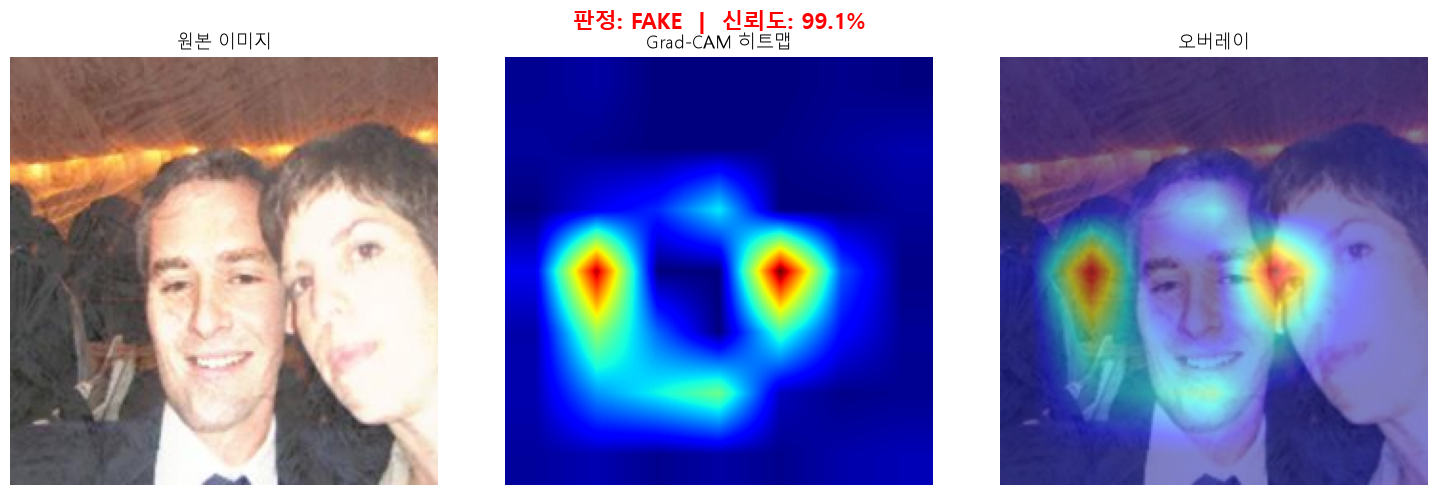


🚨 FAKE | 신뢰도: 99.1%


In [11]:
import torch
import torch.nn as nn
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


# ─── Grad-CAM 클래스 ──────────────────────────────────────
class GradCAM:
    def __init__(self, model):
        self.model    = model
        self.gradient = None
        self.activation = None

        # EfficientNet-B0 마지막 Conv 레이어에 hook 등록
        target_layer = model.feature_extractor[-1]
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activation = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradient = grad_output[0].detach()

    def generate(self, input_tensor):
        self.model.eval()

        # Forward
        output = self.model(input_tensor)
        self.model.zero_grad()

        # Backward (출력값 기준)
        output.backward()

        # Grad-CAM 계산
        weights = self.gradient.mean(dim=[2, 3], keepdim=True)  # [B, C, 1, 1]
        cam     = (weights * self.activation).sum(dim=1, keepdim=True)  # [B, 1, H, W]
        cam     = torch.relu(cam)

        # 정규화
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


# ─── 히트맵 시각화 함수 ───────────────────────────────────
def visualize_gradcam(image_path, model, device):
    # 이미지 전처리
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    # 원본 이미지 로드
    img_pil  = Image.open(image_path).convert('RGB')
    img_pil  = img_pil.resize((224, 224))
    img_orig = np.array(img_pil)

    # 텐서 변환
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)

    # Grad-CAM 생성
    gradcam = GradCAM(model)
    cam     = gradcam.generate(input_tensor)

    # 예측 결과
    model.eval()
    with torch.no_grad():
        output = model(transform(img_pil).unsqueeze(0).to(device))
        prob   = torch.sigmoid(output).item()

    is_fake   = prob < 0.5
    label     = "FAKE" if is_fake else "REAL"
    conf      = (1 - prob) * 100 if is_fake else prob * 100

    # 히트맵 오버레이
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay     = cv2.addWeighted(img_orig, 0.5, heatmap, 0.5, 0)

    # 시각화
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    color = 'red' if is_fake else 'green'

    axes[0].imshow(img_orig)
    axes[0].set_title('원본 이미지', fontsize=13)
    axes[0].axis('off')

    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title('Grad-CAM 히트맵', fontsize=13)
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title(f'오버레이', fontsize=13)
    axes[2].axis('off')

    fig.suptitle(f'판정: {label}  |  신뢰도: {conf:.1f}%',
                 fontsize=16, fontweight='bold', color=color)
    
    # 시각화 함수 맨 위에 추가
    plt.tight_layout()
    plt.show()

    print(f"\n{'🚨 FAKE' if is_fake else '✅ REAL'} | 신뢰도: {conf:.1f}%")
    return label, conf


# ─── 테스트 실행 ──────────────────────────────────────────
# 테스트 이미지 경로 (Test 폴더에서 아무거나)
TEST_IMAGE = r"C:\Users\smhrd\Desktop\딥페이크탐지모델\Dataset\Test\Fake\fake_88.jpg"

label, confidence = visualize_gradcam(TEST_IMAGE, model, DEVICE)